In [114]:
from pathlib import Path
import numpy as np
import pandas as pd

folder = Path(".") / "synthetic_runs" / "ts_123_ss_129321093809_predictors_2_regions_29_samples_150_activation_cos_agg_sum"


def load_problem():

    import os
    os.environ["JAX_PLATFORMS"] = "cpu"

    import jax
    from linear_predictors import make_problem

    
    splitted =  folder.stem.split("_")
    args = dict()
    for k, v in zip(splitted[::2], splitted[1::2], strict=True):
        args[k] = v
    system_seed = int(args["ss"])
    n_predictors = int(args["predictors"])
    n_regions = int(args["regions"])
    n_samples = int(args["samples"])

    return make_problem(
        jax.random.key(system_seed),
        n_linear_predictors=n_predictors,
        n_regions=n_regions,
        n_samples=n_samples
    )


system = load_problem()
dfs = []
predictions: list = []


run_i = 0
for ent in folder.iterdir():

    if not ent.is_file() or not ent.name.endswith(".npz"):
        continue

    _, frozen, _, delegators = ent.stem.split("_")
    frozen = frozen == "True"
    delegators = int(delegators)
    
    data = np.load(ent, allow_pickle=True)

    data_epoch = {k: data[k] for k in data.keys() if  not k.endswith("_predictions")}
    df_epoch = pd.DataFrame(data_epoch)
    df_epoch["epoch"] = np.arange(len(df_epoch))
    df_epoch["frozen"] = frozen
    df_epoch["delegators"] = delegators
    df_epoch["run_i"] = run_i
    dfs.append(df_epoch)

    all_data_predictions = {k.removesuffix("_predictions"): data[k] for k in data.keys() if k.endswith("_predictions")}
    
    n_seeds = all_data_predictions["predictors"].shape[0]
    if len(predictions) == 0:
        predictions = [[] for _ in range(n_seeds)]

    for i_seed in range(n_seeds):

        data_predictions = {k: (v[i_seed] if k not in {"x"} else v) for k, v in all_data_predictions.items()}

        for i_predictor in range(data_predictions["predictors"].shape[-1]):
            data_predictions[f"predictor_{i_predictor}"] = data_predictions["predictors"][:, i_predictor]
        del data_predictions["predictors"]

        df_prediction = pd.DataFrame(data_predictions)
        df_prediction["frozen"] = frozen
        df_prediction["delegators"] = delegators
        df_prediction["val_loss"] = df_epoch["val_loss"].values[-1]
        df_prediction["train_loss"] = df_epoch["train_loss"].values[-1]
        df_prediction["run_i"] = run_i

        predictions[i_seed].append(df_prediction)

    run_i += 1


df_epoch: pd.DataFrame = pd.concat(dfs, ignore_index=True)
predictions = [pd.concat(p, ignore_index=True) for p in predictions]

assert df_epoch.groupby("run_i")["epoch"].max().unique().size == 1

df: pd.DataFrame = df_epoch[df_epoch["epoch"] == df_epoch["epoch"].max()]

display(df.sample(8))
display(predictions[0].sample(8))

,train_loss,val_loss,predictor_variance,delegator_kl,epoch,frozen,delegators,run_i
359999,1.056311e-04,0.003097,0.001248,1.372145,59999,True,6,5
1139999,4.019736e-08,0.007669,0.116097,1.702976,59999,False,10,18
239999,8.151428e-05,0.002874,0.001248,1.074247,59999,True,4,3
599999,1.236898e-08,0.007698,0.126593,1.777032,59999,False,14,9
419999,6.172937e-08,0.006063,0.001248,0.000000,59999,True,1,6
539999,3.556670e-08,0.008374,0.118916,1.510997,59999,False,8,8
659999,4.628827e-08,0.008714,0.069961,1.725129,59999,False,6,10
899999,1.060839e-04,0.002903,0.001248,1.944273,59999,True,16,14


,x,joint_y,effective_predictors,predictor_0,predictor_1,frozen,delegators,val_loss,train_loss,run_i
2657,2.396242,-0.013464,1.963303,-0.132694,0.162377,False,16,0.008060,4.069476e-08,17
2653,2.042550,0.020375,1.994820,-0.102235,0.126518,False,16,0.008060,4.069476e-08,17
1686,-2.756778,0.037771,1.999996,0.194229,-0.118079,False,4,0.004682,5.761719e-08,11
1885,0.900940,0.000604,1.608995,0.032202,-0.006464,False,1,0.000494,1.118485e-06,12
2758,-1.261477,0.022947,1.996789,0.218574,-0.196189,False,10,0.007669,4.019736e-08,18
160,-4.605772,-0.059829,1.055282,0.175661,-0.062093,False,2,0.002961,3.969293e-07,1
2478,0.206980,0.007601,1.295145,-0.001854,0.008334,True,14,0.003125,1.083557e-04,16
2811,2.749933,0.028851,1.960355,-0.184893,0.171514,False,10,0.007669,4.019736e-08,18


Text(0, 0.5, 'Validatin loss')

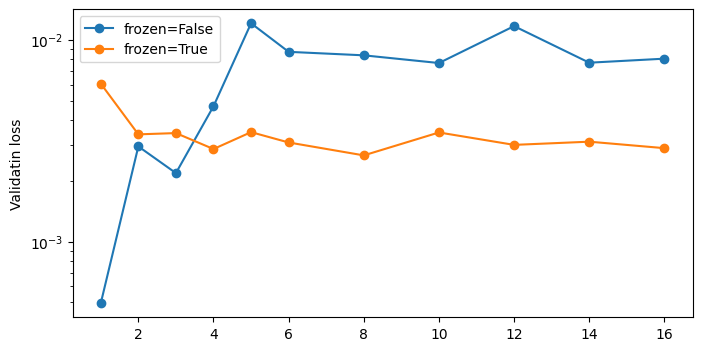

In [115]:
from matplotlib import pyplot as plt


fig, ax = plt.subplots(figsize=(8, 4))

for frozen, df_g in df.groupby("frozen"):
    
    df_g = df_g.sort_values("delegators")
    ax.plot(df_g["delegators"], df_g["val_loss"], marker="o", label=f"frozen={frozen}")

ax.legend()
ax.set_yscale("log")
ax.set_ylabel("Validatin loss")

Text(0, 0.5, 'Train loss')

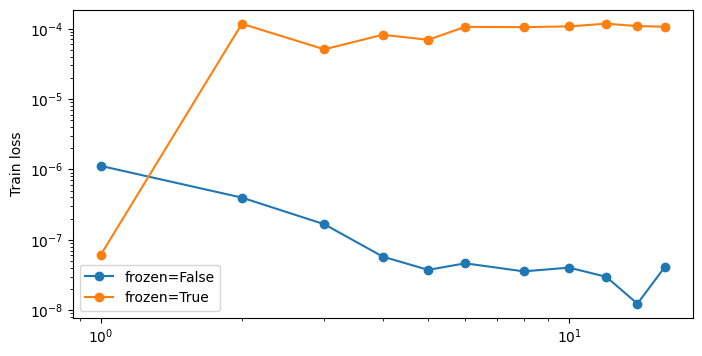

In [116]:
from matplotlib import pyplot as plt


fig, ax = plt.subplots(figsize=(8, 4))

for frozen, df_g in df.groupby("frozen"):
    
    df_g = df_g.sort_values("delegators")
    ax.plot(df_g["delegators"], df_g["train_loss"], marker="o", label=f"frozen={frozen}")

ax.legend()
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_ylabel("Train loss")

Text(0, 0.5, 'KL')

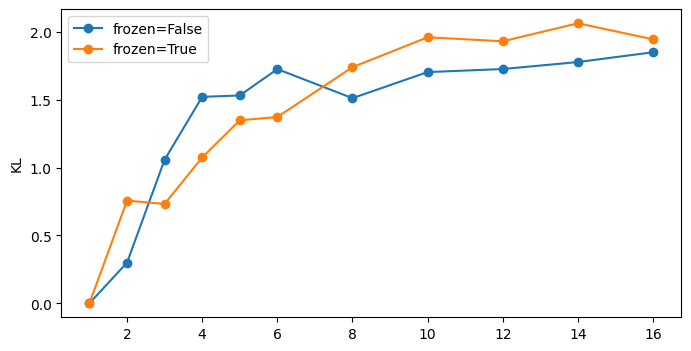

In [117]:
from matplotlib import pyplot as plt


fig, ax = plt.subplots(figsize=(8, 4))

for frozen, df_g in df.groupby("frozen"):
    
    df_g = df_g.sort_values("delegators")
    ax.plot(df_g["delegators"], df_g["delegator_kl"], marker="o", label=f"frozen={frozen}")

ax.legend()
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_ylabel("KL")

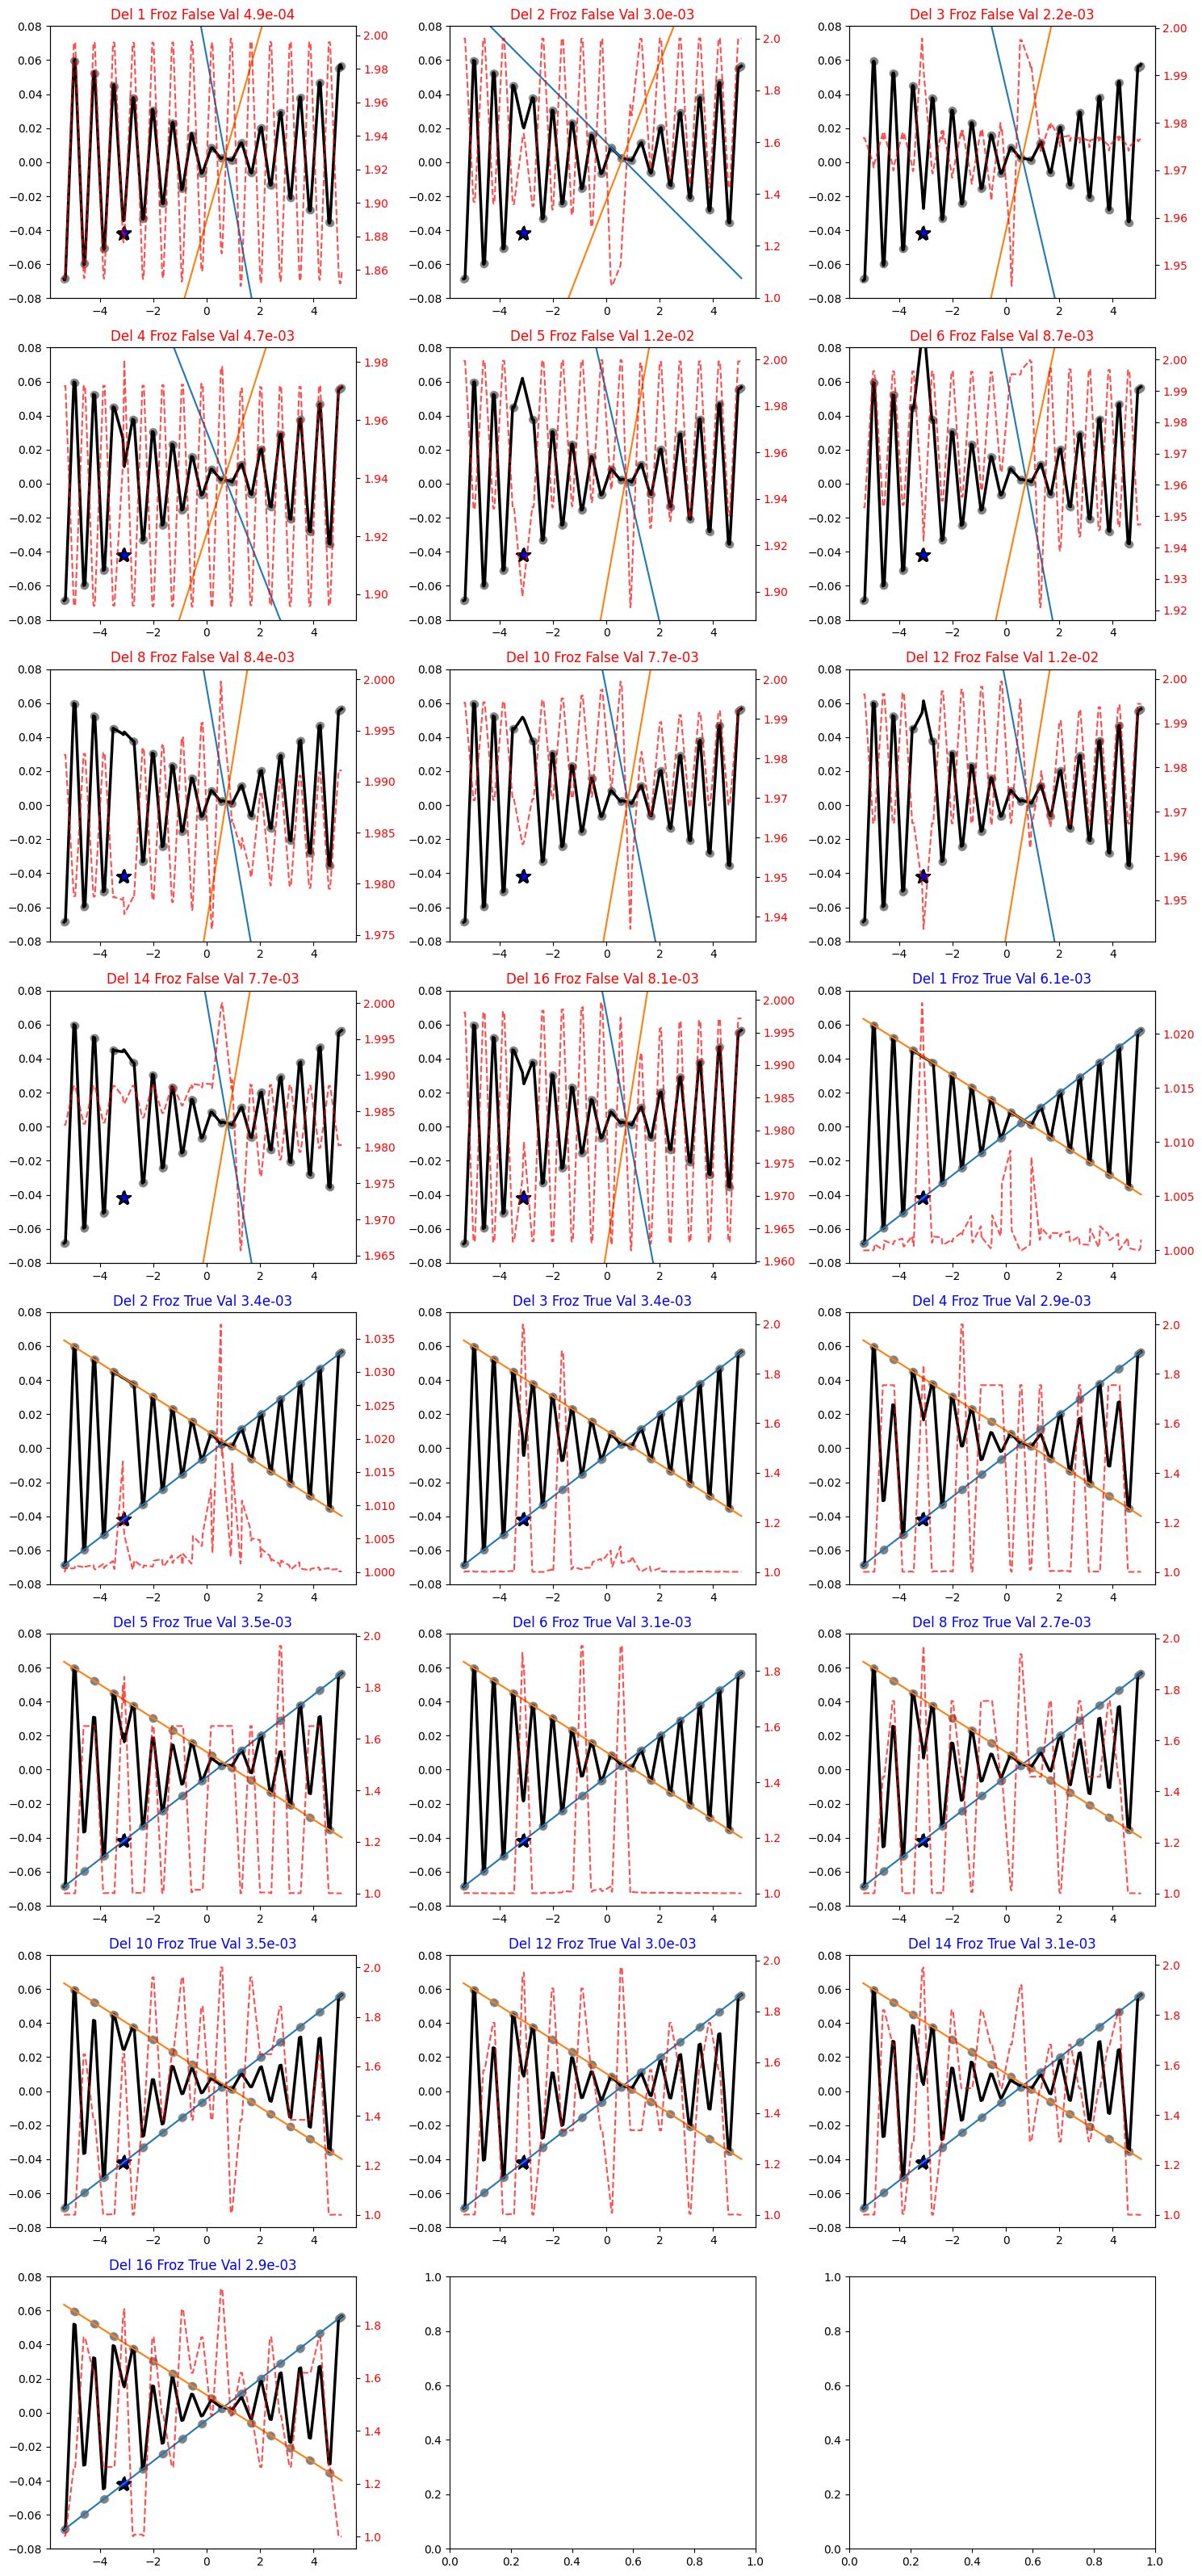

In [118]:
import math

def take_any(x: pd.Series):
    assert x.unique().size == 1
    return x.values[0]

def plot_system(ax, system, predictions: pd.DataFrame):

    predictions = predictions.sort_values("x")

    x_train, y_train = system.x[~system.val_mask], system.y[~system.val_mask]
    x_val, y_val = system.x[system.val_mask], system.y[system.val_mask]


    ax.scatter(x_train, y_train, color='gray', alpha=0.5, label='Train')
    ax.scatter(x_val, y_val, color='blue', marker='*', s=150, edgecolor='black', label='Val')
    ax.plot(system.x, predictions["joint_y"], color='black', linewidth=2.5, label='Ensemble Pred')
    
    for col in predictions.columns[predictions.columns.str.startswith("predictor_")]:
        ax.plot(system.x, predictions[col], label=col)

    # ax.legend()
    val_loss = take_any(predictions["val_loss"])
    is_frozen = take_any(predictions["frozen"])
    
    title_color = "blue" if is_frozen else "red"

    ax.set_title(
        f"Del {take_any(predictions['delegators'])} Froz {is_frozen} Val {val_loss:.1e}", 
        color=title_color
    )

    ax.set_ylim([-0.08, 0.08])

    ax_twin = ax.twinx()
    
    ax_twin.plot(system.x, predictions["effective_predictors"], color='red', linestyle='--', alpha=0.7, label='Soft Models')
    ax_twin.tick_params(axis='y', labelcolor='red')

cols = 3
display_seed = 2
N = predictions[display_seed]["run_i"].unique().size
rows = math.ceil(N / cols)

predictions[display_seed] = predictions[display_seed].sort_values(["frozen", "delegators", "x"])

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
for (_, group), ax in zip(predictions[display_seed].groupby("run_i", sort=False), axes.ravel()):
    plot_system(ax, system, group)

fig.tight_layout()

Text(0, 0.5, 'Training loss')

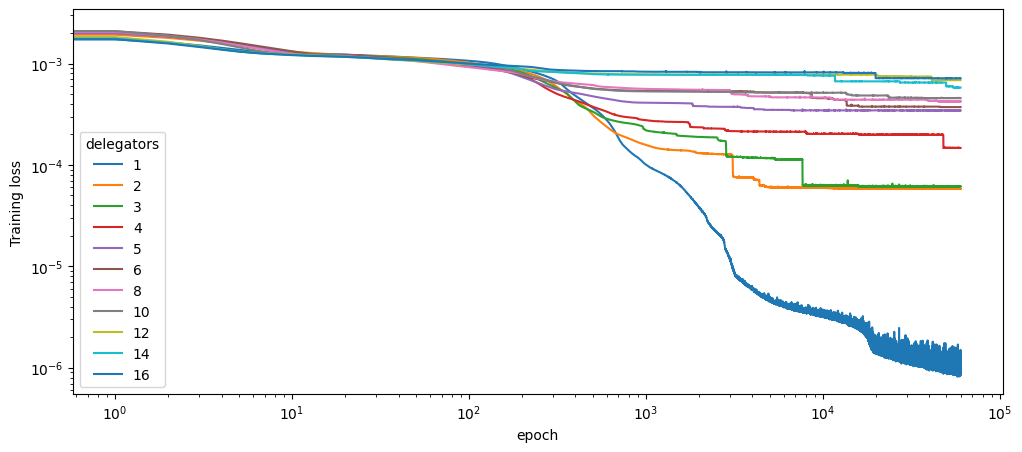

In [111]:
fig, ax = plt.subplots(figsize=(12, 5))

ax = (
    df_epoch.loc[~df_epoch["frozen"]]
    .pivot(index="epoch", columns="delegators", values="train_loss")
    .plot.line(ax=ax)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Training loss")


Text(0, 0.5, 'Valid loss')

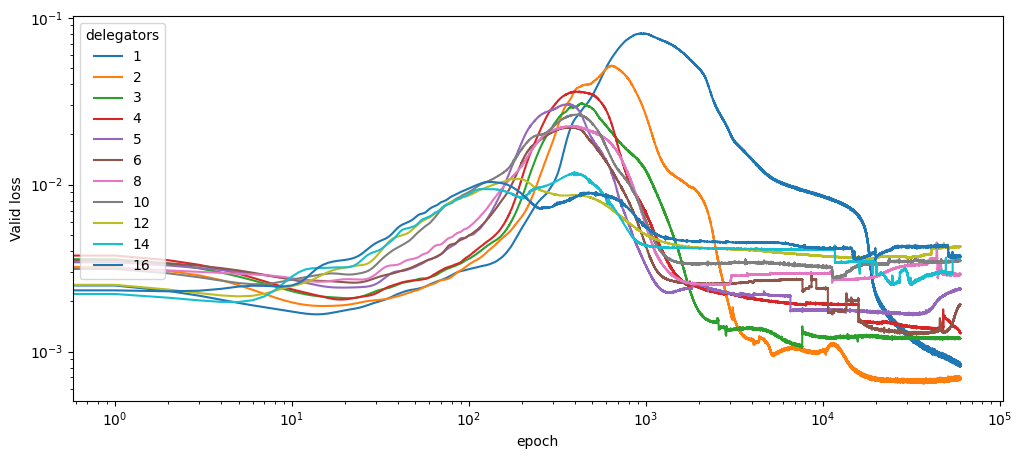

In [109]:
fig, ax = plt.subplots(figsize=(12, 5))

ax = (
    df_epoch.loc[~df_epoch["frozen"]]
    .pivot(index="epoch", columns="delegators", values="val_loss")
    .plot.line(ax=ax)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Valid loss")
